In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pyabs.core.basis import ABSBasisConfig, build_abs_basis
from pyabs.core.matrix import build_abs_matrix
from pyabs.solvers.eigensolvers import solve_eigenvalues

In [301]:
n_max=10
basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=0))

In [302]:
matrix = build_abs_matrix(basis)

In [303]:
eigenvalue_i = solve_eigenvalues(matrix)
eigenvalues = np.array(eigenvalue_i)

In [304]:
print(eigenvalues.shape)
print(eigenvalues)

(21,)
[0.+10.j 0. +9.j 0. +8.j 0. +7.j 0. +6.j 0. +5.j 0. +4.j 0. +3.j 0. +2.j
 0. +1.j 0. -0.j 0. -1.j 0. -2.j 0. -3.j 0. -4.j 0. -5.j 0. -6.j 0. -7.j
 0. -8.j 0. -9.j 0.-10.j]


In [305]:
sc = np.linspace(0, 25, num=600)
modes = np.arange(-n_max, (n_max)+1, dtype=int)
eigenscan = []
for i, q in enumerate(sc):
    basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=q))
    matrix = build_abs_matrix(basis)
    eigenscan.append(np.array(solve_eigenvalues(matrix)))

In [306]:
#eigenscan=np.array(-np.imag(eigenscan)).T
eigenscan = -np.imag(eigenscan)

In [307]:
def sort_by_continuity(eigenscan):
    sorted_scan = eigenscan.copy()
    n_steps, n_modes = eigenscan.shape

    for i in range(1, n_steps):
        prev = sorted_scan[i - 1]
        curr = sorted_scan[i].copy()

        used = set()
        new_order = np.zeros(n_modes, dtype=int)
        for j in range(n_modes):
            # find the closest unused eigenvalue in curr to prev[j]
            dists = np.abs(curr - prev[j])
            dists[list(used)] = np.inf
            best = np.argmin(dists)
            new_order[j] = best
            used.add(best)

        sorted_scan[i] = curr[new_order]

    return sorted_scan

eigenscan_tracked = sort_by_continuity(eigenscan)

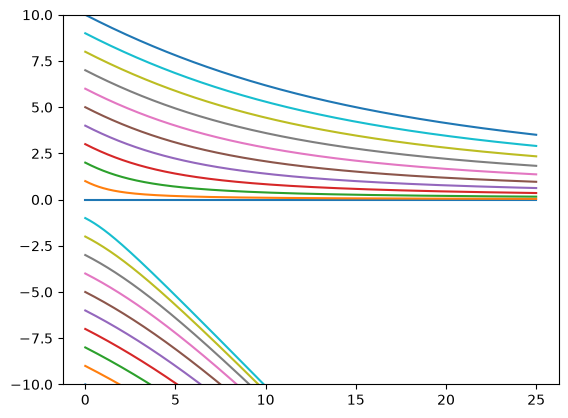

In [308]:
fig, ax = plt.subplots()
ax.set_ylim(-10,10)
#for i in range(len(modes)):
#    plt.scatter(sc, eigenscan[i])
plt.plot(sc, eigenscan_tracked)

compare with analytical solutions from burov
double check where the complex number went in burov